# Obesity Project
**Problem Statement:** Socio-Economic Influences on Obesity Rates.

**Author:** Vincent Chan, Sandeep Mukkala, Jack Lichwa

**Affiliation:** Seattle University

**Course:** DATA-5100 Foundation of Data Science

**Professor:** Dr. Brian Fischer

**Date:** November 2, 2025

**Introduction:**

- Obesity is a growing global health concern, it increases the risk of cardiovascular diseases, diabetes, chronic diseases and places considerable strain on healthcare systems. To some extent genetics play a role, but socioeconomic factors often play an important role in obesity prevalence in populations across different countries and they emerge as the strongest predictors of obesity.

- Here we are predicting the obesity rates by using different socio-economic factors like country's GDP, lifestyle behaviors, and health indicators. We start linear regression, quadratic regression and then finaly we use multiple linear regression model and we will compare all the three.

- We are using Python libraries like Pandas, sklearn, statsmodels, Matplotlib, Numpy and Seaborn for visualization and analysis purpose and requests for calling and getting response from API to load Internet access Information across different states.

**Data Source:**

- **Source:** 
    - [WHO Obesity data](https://github.com/SU-MSDS-Obesity-Class-2025/Obesity/blob/main/data/who_obesity_core_data.csv)
    - [GDP data](https://github.com/SU-MSDS-Obesity-Class-2025/Obesity/blob/main/data/GDP_data.csv)

- **Description:**
    - The data in these datasets is from (1990-2022) year.

    - WHO Obesity dataset: 
        - The data in this dataset is collected from Global Health Observatory (GHO)
          (Web source: https://www.who.int/data/gho). The GHO is the WHO's main portal for health-related statistics, providing access to over 1,000 indicators out of them we have collected data for 9 most relavant indicators  
        - It contains Date, Dim1, Dim1Type, Dim2, Dim2Type, Dim3, Dim3Type, High, Id, IndicatorCode, IndicatorName, Low, NumericValue, ParentLocation, ParentLocationCode, SpatialDim, SpatialDimType, TimeDim, TimeDimType, TimeDimensionBegin, TimeDimensionEnd, TimeDimensionValue, Value as columns. It contains 146334 rows in csv format. 

    - GDP dataset: 

        - The GDP data is collected from World Bank Group (https://api.worldbank.org/v2/en/indicator/NY.GDP.MKTP.CD?downloadformat=csv). It contains GDP data of every country by year with following columns: Country Name, Country Code, Indicator Name, Indicator Code, Year and contains 265 rows in csv format.


    Relavent Indicators:

    | Indicator Code                         | Indicator Name                                                                                          |
    |----------------------------------------|---------------------------------------------------------------------------------------------------------|
    | NCD_BMI_30A.                           | Prevalence of obesity among adults, BMI ≥ 30 (age-standardized estimate, %).                            |
    | NCD_DIABETES_PREVALENCE_CRUDE          | Prevalence of diabetes, crude (%)                                                                       |
    | NCD_GLUC_03                            | Raised fasting blood glucose (≥ 7.0 mmol/L) (age-standardized, %)                                       |
    | NCD_PAA                                | Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate, %) |
    | SI_POV_DAY1                            | Proportion of population below the international poverty line (US$1.90/day, %)                          |
    | WHS5_512                               | Population using solid fuels (%).                                                                       |
    | WHOSIS_000001                          | Life expectancy at birth (years)                                                                        |
    | WSH_SANITATION_BASIC                   | Population using at least basic sanitation services (%)                                                 |
    | PHE_HHAIR_PROP_POP_POLLUTING_FUELS     | Proportion of population with primary reliance on polluting fuels (%)                                   |  
    | GDP_CURRENT_USD                        | GDP per capita (World Bank)                                                                             |      

## 1. Import Necessary Libraries

In [1]:
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Model preprocessing
from sklearn.preprocessing import StandardScaler

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.anova import anova_lm

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Set default visualization style
sns.set_style('whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_colwidth', None)  
pd.set_option('display.max_columns', None) 


## 2. Load Data

In [2]:
df_who = pd.read_csv('../data/who_obesity_core_data.csv')

df_who.shape

/var/folders/c_/xvyl08rd0w152pky7b5zssvw0000gn/T/ipykernel_5786/2563650578.py:1: DtypeWarning: Columns (0,6,7,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df_who = pd.read_csv('../data/who_obesity_core_data.csv')


(144301, 28)

In [3]:
df_who.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144301 entries, 0 to 144300
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Comments            4 non-null       object 
 1   DataSourceDim       0 non-null       float64
 2   DataSourceDimType   0 non-null       float64
 3   Date                144301 non-null  object 
 4   Dim1                144301 non-null  object 
 5   Dim1Type            144301 non-null  object 
 6   Dim2                98214 non-null   object 
 7   Dim2Type            98214 non-null   object 
 8   Dim3                0 non-null       float64
 9   Dim3Type            0 non-null       float64
 10  High                131212 non-null  float64
 11  Id                  144301 non-null  float64
 12  IndicatorCode       144301 non-null  object 
 13  IndicatorName       144301 non-null  object 
 14  Low                 131212 non-null  float64
 15  NumberOfRecords     0 non-null    

Our initial set of indicators with >abs(0.4) correlation to our obesity Indicator(`NCD_BMI_30A' - "Percentage of obesity among adults"):

In [4]:
indicators_list = df_who[['IndicatorCode', 'IndicatorName']].drop_duplicates()
indicators_list.sort_values('IndicatorCode')

,IndicatorCode,IndicatorName
0,NCD_BMI_30A,"Prevalence of obesity among adults, BMI &GreaterEqual; 30 (age-standardized estimate) (%)"
20790,NCD_DIABETES_PREVALENCE_CRUDE,"Prevalence of diabetes, crude"
62370,NCD_GLUC_03,Raised fasting blood glucose (>= 7.0 mmol/L) (crude estimate)
84000,NCD_PAA,Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate) (%)
123799,PHE_HHAIR_PROP_POP_POLLUTING_FUELS,Proportion of population with primary reliance on polluting fuels and technologies for cooking (%)
98214,WHOSIS_000001,Life expectancy at birth (years)
111150,WSH_SANITATION_BASIC,Population using at least basic sanitation services (%)


## 3. Evaluate Data Structure and Clean Data

In this section, we will evaluate the structure of the dataset and perform necessary data cleaning steps to prepare it for analysis.

### 3.1 Dimension Evaluation in WHO Dataset

Our dataset contains multiple dimensions, including TimeDim (Years) and SpatialDimType (Geographic Level) and Dim1,Dim2 with various categories per each indicator

We want our analysis to focus on country-level data for the year 2012 and indicators dimensions which summarize entire population.

Filter WHO data to 2012 year only (TimeDim).

In [5]:
df_who['TimeDim'].value_counts()

TimeDim
2013.0    4877
2012.0    4877
2011.0    4877
2014.0    4877
2009.0    4874
2010.0    4874
2008.0    4871
2006.0    4871
2007.0    4871
2005.0    4868
2003.0    4868
2002.0    4868
2004.0    4868
2001.0    4862
2000.0    4856
2016.0    4259
2015.0    4259
2017.0    4254
2018.0    4246
2019.0    4241
2020.0    4235
2021.0    4228
2022.0    3627
1999.0    3111
1998.0    3111
1995.0    3111
1997.0    3111
1990.0    3111
1994.0    3111
1996.0    3111
1992.0    3111
1991.0    3111
1993.0    3111
1980.0     618
1989.0     618
1985.0     618
1984.0     618
1981.0     618
1988.0     618
1987.0     618
1982.0     618
1983.0     618
1986.0     618
2023.0     603
Name: count, dtype: int64

### 3.2 Filter common dimensions 

Our focus is on country-level data for the year 2012.

Filtering dimensions which common across all indictators like SpatialDimType (Country) and TimeDim (Year)

In [6]:
df_who_clean= df_who[df_who['TimeDim'] == 2012.0].copy()
df_who_clean.shape

(4877, 28)

Filter to country-level data only (SpatialDimType).

In [7]:
df_who_clean['SpatialDimType'].unique()

array(['COUNTRY', 'WORLDBANKINCOMEGROUP', 'REGION', 'GLOBAL'],
      dtype=object)

In [8]:
df_who_clean = df_who_clean[df_who_clean['SpatialDimType'] == 'COUNTRY']
df_who_clean.shape

(4637, 28)

### 3.3 Rename common dimensions

In [9]:
df_who_clean.rename(columns={'SpatialDim': 'CountryCode', 'TimeDim': 'Year'}, inplace=True)
df_who_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4637 entries, 32 to 144221
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Comments            0 non-null      object 
 1   DataSourceDim       0 non-null      float64
 2   DataSourceDimType   0 non-null      float64
 3   Date                4637 non-null   object 
 4   Dim1                4637 non-null   object 
 5   Dim1Type            4637 non-null   object 
 6   Dim2                2961 non-null   object 
 7   Dim2Type            2961 non-null   object 
 8   Dim3                0 non-null      float64
 9   Dim3Type            0 non-null      float64
 10  High                4086 non-null   float64
 11  Id                  4637 non-null   float64
 12  IndicatorCode       4637 non-null   object 
 13  IndicatorName       4637 non-null   object 
 14  Low                 4086 non-null   float64
 15  NumberOfRecords     0 non-null      float64
 16  NumericV

In [10]:
df_who_clean.head()

,Comments,DataSourceDim,DataSourceDimType,Date,Dim1,Dim1Type,Dim2,Dim2Type,Dim3,Dim3Type,High,Id,IndicatorCode,IndicatorName,Low,NumberOfRecords,NumericValue,ParentLocation,ParentLocationCode,CountryCode,SpatialDimType,Year,TimeDimType,TimeDimensionBegin,TimeDimensionEnd,TimeDimensionValue,Value,source_file
32,NaN,NaN,NaN,2024-02-29T16:06:41.017+01:00,SEX_FMLE,SEX,AGEGROUP_YEARS18-PLUS,AGEGROUP,NaN,NaN,20.889911,15216.0,NCD_BMI_30A,"Prevalence of obesity among adults, BMI &GreaterEqual; 30 (age-standardized estimate) (%)",18.140502,NaN,19.486509,Western Pacific,WPR,MYS,COUNTRY,2012.0,YEAR,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00,2012.0,19.5 [18.1-20.9],NCD_BMI_30A.csv
34,NaN,NaN,NaN,2024-02-29T16:06:41.017+01:00,SEX_MLE,SEX,AGEGROUP_YEARS18-PLUS,AGEGROUP,NaN,NaN,24.798070,15627.0,NCD_BMI_30A,"Prevalence of obesity among adults, BMI &GreaterEqual; 30 (age-standardized estimate) (%)",16.966379,NaN,20.802629,Americas,AMR,BRB,COUNTRY,2012.0,YEAR,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00,2012.0,20.8 [17.0-24.8],NCD_BMI_30A.csv
46,NaN,NaN,NaN,2024-02-29T16:06:41.017+01:00,SEX_FMLE,SEX,AGEGROUP_YEARS18-PLUS,AGEGROUP,NaN,NaN,47.460297,19641.0,NCD_BMI_30A,"Prevalence of obesity among adults, BMI &GreaterEqual; 30 (age-standardized estimate) (%)",40.112865,NaN,43.762907,Eastern Mediterranean,EMR,QAT,COUNTRY,2012.0,YEAR,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00,2012.0,43.8 [40.1-47.5],NCD_BMI_30A.csv
52,NaN,NaN,NaN,2024-02-29T16:06:41.017+01:00,SEX_MLE,SEX,AGEGROUP_YEARS18-PLUS,AGEGROUP,NaN,NaN,31.529307,21753.0,NCD_BMI_30A,"Prevalence of obesity among adults, BMI &GreaterEqual; 30 (age-standardized estimate) (%)",11.706504,NaN,20.735496,Europe,EUR,MKD,COUNTRY,2012.0,YEAR,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00,2012.0,20.7 [11.7-31.5],NCD_BMI_30A.csv
109,NaN,NaN,NaN,2024-02-29T16:06:41.017+01:00,SEX_FMLE,SEX,AGEGROUP_YEARS18-PLUS,AGEGROUP,NaN,NaN,53.625965,50048.0,NCD_BMI_30A,"Prevalence of obesity among adults, BMI &GreaterEqual; 30 (age-standardized estimate) (%)",46.044499,NaN,49.901748,Western Pacific,WPR,MHL,COUNTRY,2012.0,YEAR,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00,2012.0,49.9 [46.0-53.6],NCD_BMI_30A.csv


### 3.4 Filter indicator-specific dimensions

Dimensions available for each indicator:

In [11]:
for i,ind in indicators_list.iterrows(): 
      code = ind['IndicatorCode']
      name = ind['IndicatorName']
      dims = df_who_clean[df_who_clean['IndicatorCode'] == code][['Dim1', 'Dim2']].drop_duplicates()
      print(f"\nIndicator: {code} - {name}")
      print(f"  Dim1 values: {dims['Dim1'].unique()}")
      print(f"  Dim2 values: {dims['Dim2'].unique()}")


Indicator: NCD_BMI_30A - Prevalence of obesity among adults, BMI &GreaterEqual; 30 (age-standardized estimate) (%)
  Dim1 values: ['SEX_FMLE' 'SEX_MLE' 'SEX_BTSX']
  Dim2 values: ['AGEGROUP_YEARS18-PLUS']

Indicator: NCD_DIABETES_PREVALENCE_CRUDE - Prevalence of diabetes, crude
  Dim1 values: ['SEX_FMLE' 'SEX_MLE' 'SEX_BTSX']
  Dim2 values: ['AGEGROUP_YEARS18-PLUS' 'AGEGROUP_YEARS30-PLUS']

Indicator: NCD_GLUC_03 - Raised fasting blood glucose (>= 7.0 mmol/L) (crude estimate)
  Dim1 values: ['SEX_FMLE' 'SEX_BTSX' 'SEX_MLE']
  Dim2 values: ['AGEGROUP_YEARS18-PLUS']

Indicator: NCD_PAA - Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate) (%)
  Dim1 values: ['SEX_FMLE' 'SEX_MLE' 'SEX_BTSX']
  Dim2 values: ['AGEGROUP_YEARS18-PLUS']

Indicator: WHOSIS_000001 - Life expectancy at birth (years)
  Dim1 values: ['SEX_MLE' 'SEX_FMLE' 'SEX_BTSX']
  Dim2 values: [nan]

Indicator: WSH_SANITATION_BASIC - Population using at least basic sanitation se

Dimensions per indicator to be evaluated next.


Based on the dimension evaluation, we will filter the dataset to include only the  dimensions which represent total population for our analysis. Total population dimensions for each indicator are as follows:

NCD_BMI_30A (Obesity prevalence):
      Dim1: All Genders (SEX_BTSX)
      Dim2: Age 18+ (AGEGROUP_YEARS18-PLUS)

  NCD_DIABETES_PREVALENCE_CRUDE (Diabetes prevalence):
      Dim1: All Genders (SEX_BTSX)
      Dim2: Age 18+ (AGEGROUP_YEARS18-PLUS)

  NCD_GLUC_03 (Raised blood glucose):
      Dim1: All Genders (SEX_BTSX)
      Dim2: Age 18+ (AGEGROUP_YEARS18-PLUS)

  NCD_PAA (Physical inactivity):
      Dim1: All Genders (SEX_BTSX)
      Dim2: Age 18+ (AGEGROUP_YEARS18-PLUS)

  SI_POV_DAY1 (Poverty headcount ratio):
      Dim1: None
      Dim2: None

  WHOSIS_000001 (Life expectancy):
      Dim1: All Genders (SEX_BTSX)
      Dim2: None

  WSH_SANITATION_BASIC (Basic sanitation services):
      Dim1: Total Population (RESIDENCEAREATYPE_TOTL)
      Dim2: None

  PHE_HHAIR_PROP_POP_POLLUTING_FUELS (Population using polluting fuels):
      Dim1: Total Population (RESIDENCEAREATYPE_TOTL)
      Dim2: None

In [12]:
# Define dimension criteria for each indicator
indicator_dims = {
    'NCD_BMI_30A': {'Dim1': 'SEX_BTSX', 'Dim2': 'AGEGROUP_YEARS18-PLUS'},
    'NCD_DIABETES_PREVALENCE_CRUDE': {'Dim1': 'SEX_BTSX', 'Dim2': 'AGEGROUP_YEARS18-PLUS'},
    'NCD_GLUC_03': {'Dim1': 'SEX_BTSX', 'Dim2': 'AGEGROUP_YEARS18-PLUS'},
    'NCD_PAA': {'Dim1': 'SEX_BTSX', 'Dim2': 'AGEGROUP_YEARS18-PLUS'},
    'WHOSIS_000001': {'Dim1': 'SEX_BTSX', 'Dim2': None},
    'WSH_SANITATION_BASIC': {'Dim1': 'RESIDENCEAREATYPE_TOTL', 'Dim2': None},
    'PHE_HHAIR_PROP_POP_POLLUTING_FUELS': {'Dim1': 'RESIDENCEAREATYPE_TOTL', 'Dim2': None}
}

# Filter data for each indicator based on its dimension criteria
relevant_indicator_data = []


for indicator_code, dims in indicator_dims.items():
    # Get data for this indicator
    indicator_data = df_who_clean[df_who_clean['IndicatorCode'] == indicator_code].copy()

    # Apply dimension filters
    if dims.get('Dim1') :
        indicator_data = indicator_data[indicator_data['Dim1'] == dims['Dim1']]

    if dims.get('Dim2') :
        indicator_data = indicator_data[indicator_data['Dim2'] == dims['Dim2']]

    relevant_indicator_data.append(indicator_data)

# Combine all filtered dataframes
df_who_clean = pd.concat(relevant_indicator_data, ignore_index=True)


print(f"Shape after dimension filtering: {df_who_clean.shape}")
print("\nRecords per indicator:")
print(df_who_clean['IndicatorCode'].value_counts())


Shape after dimension filtering: (1362, 28)

Records per indicator:
IndicatorCode
NCD_BMI_30A                           199
NCD_DIABETES_PREVALENCE_CRUDE         199
NCD_GLUC_03                           195
NCD_PAA                               195
WSH_SANITATION_BASIC                  195
PHE_HHAIR_PROP_POP_POLLUTING_FUELS    194
WHOSIS_000001                         185
Name: count, dtype: int64


### 3.5 Drop unnecessary columns

We will drop columns that are not needed for our analysis to streamline the dataset.


In [13]:
# List all columns in the dataframe
df_who_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1362 entries, 0 to 1361
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Comments            0 non-null      object 
 1   DataSourceDim       0 non-null      float64
 2   DataSourceDimType   0 non-null      float64
 3   Date                1362 non-null   object 
 4   Dim1                1362 non-null   object 
 5   Dim1Type            1362 non-null   object 
 6   Dim2                788 non-null    object 
 7   Dim2Type            788 non-null    object 
 8   Dim3                0 non-null      float64
 9   Dim3Type            0 non-null      float64
 10  High                1163 non-null   float64
 11  Id                  1362 non-null   float64
 12  IndicatorCode       1362 non-null   object 
 13  IndicatorName       1362 non-null   object 
 14  Low                 1163 non-null   float64
 15  NumberOfRecords     0 non-null      float64
 16  Numeri

In [14]:
relevant_columns = ['IndicatorCode', 'CountryCode', 'Year', 'NumericValue']
df_who_clean = df_who_clean[relevant_columns]

df_who_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1362 entries, 0 to 1361
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   IndicatorCode  1362 non-null   object 
 1   CountryCode    1362 non-null   object 
 2   Year           1362 non-null   float64
 3   NumericValue   1358 non-null   float64
dtypes: float64(2), object(2)
memory usage: 42.7+ KB


Transpose IndicatorCode to columns for easier analysis.

In [15]:
df_who_clean_pivot = df_who_clean.pivot(index=['CountryCode', 'Year'],
                                    columns='IndicatorCode',
                                    values='NumericValue')
df_who_clean_pivot = df_who_clean_pivot.reset_index()
df_who_clean_pivot.columns.name = None

df_who_clean_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 9 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   CountryCode                         203 non-null    object 
 1   Year                                203 non-null    float64
 2   NCD_BMI_30A                         199 non-null    float64
 3   NCD_DIABETES_PREVALENCE_CRUDE       199 non-null    float64
 4   NCD_GLUC_03                         191 non-null    float64
 5   NCD_PAA                             195 non-null    float64
 6   PHE_HHAIR_PROP_POP_POLLUTING_FUELS  194 non-null    float64
 7   WHOSIS_000001                       185 non-null    float64
 8   WSH_SANITATION_BASIC                195 non-null    float64
dtypes: float64(8), object(1)
memory usage: 14.4+ KB


## 4. Merging GDP data set

In [16]:
gdp_data = pd.read_csv(
    'https://raw.githubusercontent.com/SU-MSDS-Obesity-Class-2025/Obesity/refs/heads/main/data/GDP_data.csv'
)

In [17]:
# select year columns (YYYY)
year_cols = [c for c in gdp_data.columns if str(c).isdigit() and len(str(c)) == 4]


gdp_data_tidy = (
    gdp_data.melt(
        id_vars=['Country Code'],
        value_vars=year_cols,
        var_name='Year',
        value_name='GDP_CURRENT_USD'
    )
    .rename(columns={'Country Code': 'CountryCode'})
)

# converting type
gdp_data_tidy['Year'] = gdp_data_tidy['Year'].astype(int)

# merge
complete_indicators_data = df_who_clean_pivot.merge(gdp_data_tidy, on=['CountryCode', 'Year'], how='left')

# Converting datatype of year column from float to period
complete_indicators_data["Year"] = pd.to_datetime(complete_indicators_data["Year"].astype('Int64'),format='%Y')
complete_indicators_data["Year"] = complete_indicators_data["Year"].dt.to_period('Y')

# saved complete indicators data to csv file
complete_indicators_data.to_csv("../data/complete_indicators_data.csv")

In [18]:
complete_indicators_data.head(10)

,CountryCode,Year,NCD_BMI_30A,NCD_DIABETES_PREVALENCE_CRUDE,NCD_GLUC_03,NCD_PAA,PHE_HHAIR_PROP_POP_POLLUTING_FUELS,WHOSIS_000001,WSH_SANITATION_BASIC,GDP_CURRENT_USD
0,AFG,2012,10.262612,14.184703,8.0,27.400879,77.1,59.922106,38.86031,1.990733e+10
1,AGO,2012,8.522078,12.943757,5.3,18.960588,54.4,59.462337,43.59147,1.280529e+11
2,ALB,2012,17.524008,9.170288,8.0,21.552830,29.2,77.341950,96.21027,1.224650e+10
3,AND,2012,16.665833,8.652432,8.9,30.928501,0.0,NaN,100.00000,3.188653e+09
4,ARE,2012,31.948605,20.597441,6.9,58.496910,0.0,80.306185,99.11790,3.846101e+11
5,ARG,2012,26.258084,9.880197,9.9,35.863937,0.5,76.176055,93.22680,5.459824e+11
6,ARM,2012,20.321731,10.536173,11.6,24.582327,3.2,73.669221,91.68617,1.061932e+10
7,ASM,2012,72.259849,31.910962,NaN,NaN,NaN,NaN,NaN,6.400000e+08
8,ATG,2012,26.789513,16.949517,11.0,34.238285,0.0,75.663127,97.37247,1.364730e+09
9,AUS,2012,25.741681,7.377310,7.2,26.056353,0.0,82.272473,99.99674,1.547532e+12


## 5. Ploting Barplot for missing values
- shows the percentage count of missing data per column

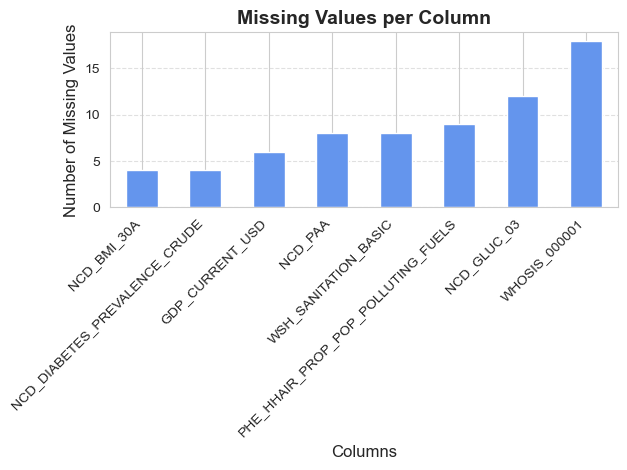

In [19]:
indicator_columns = complete_indicators_data.columns.difference(['CountryCode','Year'])

indicator_columns

missing_counts = complete_indicators_data[indicator_columns].isna().sum().sort_values(ascending=True)

missing_counts.plot(kind='bar', color='cornflowerblue')

plt.title("Missing Values per Column", fontsize=14, fontweight='bold')
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Number of Missing Values", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

## 6. Data imputation

In [20]:
complete_indicators_data.isna().sum().to_frame(name = 'Number of Missing Values')

,Number of Missing Values
CountryCode,0
Year,0
NCD_BMI_30A,4
NCD_DIABETES_PREVALENCE_CRUDE,4
NCD_GLUC_03,12
NCD_PAA,8
PHE_HHAIR_PROP_POP_POLLUTING_FUELS,9
WHOSIS_000001,18
WSH_SANITATION_BASIC,8
GDP_CURRENT_USD,6


Dropping rows with missing target indicator values (NCD_BMI_30A).

In [21]:
missing_obesity = complete_indicators_data[complete_indicators_data['NCD_BMI_30A'].isna()]
print(f"Countries missing NCD_BMI_30A:{len(missing_obesity)}")
print("\nCountries:")
print(missing_obesity['CountryCode'].unique())

complete_indicators_data = complete_indicators_data.dropna(subset=['NCD_BMI_30A'])  

Countries missing NCD_BMI_30A:4

Countries:
['FRO' 'MCO' 'SDN736' 'SMR']


In [22]:
predictor_variables = complete_indicators_data.columns[3:]

imputer = IterativeImputer()
numerical_predictors = complete_indicators_data[predictor_variables].select_dtypes(include = ['number']).columns.to_list()
numerical_predictors

['NCD_DIABETES_PREVALENCE_CRUDE',
 'NCD_GLUC_03',
 'NCD_PAA',
 'PHE_HHAIR_PROP_POP_POLLUTING_FUELS',
 'WHOSIS_000001',
 'WSH_SANITATION_BASIC',
 'GDP_CURRENT_USD']

In [23]:
imputer.fit(complete_indicators_data.loc[:, numerical_predictors])

IterativeImputer()

In [24]:
complete_indicators_data.loc[:, numerical_predictors] = imputer.transform(complete_indicators_data.loc[:,numerical_predictors])

In [25]:
complete_indicators_data.isna().sum().to_frame(name = 'Number of Missing Values')

,Number of Missing Values
CountryCode,0
Year,0
NCD_BMI_30A,0
NCD_DIABETES_PREVALENCE_CRUDE,0
NCD_GLUC_03,0
NCD_PAA,0
PHE_HHAIR_PROP_POP_POLLUTING_FUELS,0
WHOSIS_000001,0
WSH_SANITATION_BASIC,0
GDP_CURRENT_USD,0


### 6.1 Renaming variables

In [26]:
complete_indicators_data = complete_indicators_data.rename(
    columns = {
        'NCD_BMI_30A': 'BMI',
        'NCD_DIABETES_PREVALENCE_CRUDE': 'prevalence_of_diabetes',
        'NCD_GLUC_03': 'blood_glucose',
        'NCD_PAA': 'physical_activity',
        'PHE_HHAIR_PROP_POP_POLLUTING_FUELS': 'polluting_cooking_fuel_rate',
        'WHOSIS_000001': 'life_expectancy',
        'WSH_SANITATION_BASIC': 'basic_sanitation_rate',
        'GDP_CURRENT_USD': 'GDP'
        })

## 7. Exploratory Data Analysis
### 7.1 PairPlot to explore relationship between Target (Y) and Independent variables (X) after imputing

In [27]:
indicator_columns = complete_indicators_data.columns.difference(['CountryCode', 'Year'])

fig = sns.pairplot(complete_indicators_data[indicator_columns], y_vars=['BMI'], kind='reg', plot_kws={'line_kws':{'color':'blue'}, 'scatter_kws': {'alpha':0.5, 'color': 'k', 's': 7}})

for ax in fig.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=45, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

Interpretation:

GDP_per_capita_2011 - Weak positive
- Countries with higher GDP per capita tend to have somewhat higher obesity rates, but the relationship appears uneven, may be due to economic disparities.

NCD_DIABETES_PREVALENCE_CRUDE - Strong positive:
- Strong positive correlation exists, countries with higher diabetes prevalence also show higher obesity prevalence.

NCD_GLUC_03 - Strong positive:
- Similar to diabetes, elevated glucose levels are strongly associated with obesity.

NCD_PAA - Moderate positive:
- Physical inactivity increases, obesity also tend to increase, but with more scatter which might indicate other interacting factors like income urbanisation.

PHE_HHAIR_PROP_POP_POLLUTING_FUELS - Negative:
- Higher usage of polluting fuels corresponding to lower obesity levels might be due to limited sedentary lifestyle/industrialization.

WHOSIS_000001 - Moderately positive:
- Countries with higher life expectancy tend to have higher obesity, reflects a good health care in the country, might not necessarily causality.

WSH_SANITATION_B_ASIC - Positive: 
- Improved sanitation is linked to higher obesity rates, which indicates better economic development and urbanization.

### 7.2 HeatMap

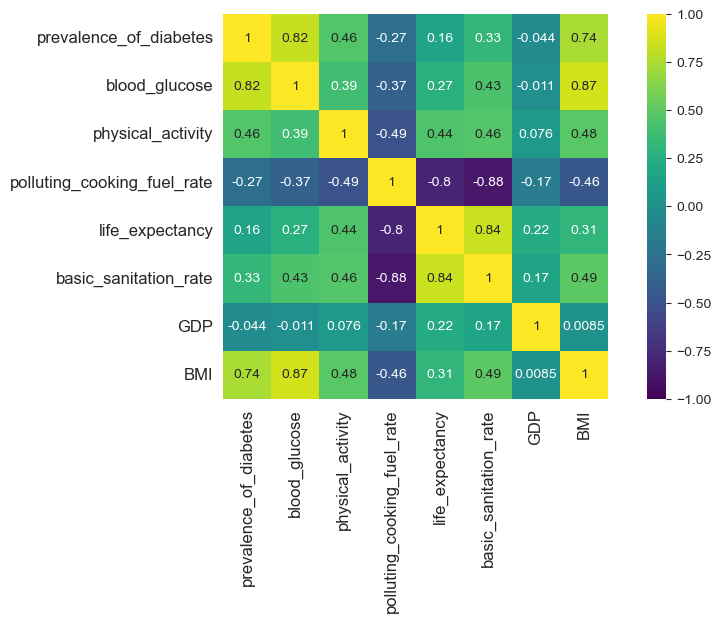

In [28]:
predictors = complete_indicators_data.columns[3:]
numerical_predictors = (complete_indicators_data[predictors].select_dtypes(include=['number']).columns.to_list())
corr_matrix = complete_indicators_data[numerical_predictors + ['BMI']].corr()
    
plt.figure( figsize=(10, 5))
sns.heatmap(corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap="viridis")
plt.tick_params(labelsize=12)
plt.show()

Interpreattion:

GDP_CURRENT_USD(r=0.0085):
- Very weak positive correlation. Countries with higher GDP per capita tend to have slightly higher obesity rates, but the relationship appears very weak due to income inequalities and other lifestyle factors.

NCD_DIABETES_PREVALENCE_CRUDE(r = 0.74):
- Strong positive correlation exists, higher diabetes rates are strongly linked higher obesity prevalence.

NCD_GLUC_03(r = 0.87):
- Strong positive correlation. Similar to diabetes, elevated glucose levels are strongly associated with obesity.

NCD_PAA(r = 0.48):
- Moderate positive correlation. Countries with higher physical inactivity has higher obesity rates.

PHE_HHAIR_PROP_POP_POLLUTING_FUELS(r = -0.46):
- Negative correlation. Countries relying on polluting fuels have lower obesity rates.

WHOSIS_000001(r = 0.31):
- Moderately positive correlation. Countries with higher life expectancy tend to have higher obesity, reflects a good health care in the country, might not necessarily causality.

WSH_SANITATION_BASIC(r = 0.49): 
- Positive correlation. Improved sanitation is linked to higher obesity rates, might be due to more sedentary life style among people living in these countries because of better economic development and urbanization.

## 8. Modeling on the data for year 2012.

- we choose the data for year 2012 for all indicators to predict the obesity rates since socio-economic factors don't changes drastically within a spane of 10(apprx.) years

In [29]:
complete_indicators_data['Year'].dtype
complete_indicators_data_2012 = complete_indicators_data[complete_indicators_data['Year'].dt.year == 2012]

complete_indicators_data_2012.head()

complete_indicators_data_2012.to_csv("../data/complete_indicators_data_2012.csv")

### 8.1 Single input model:

In [30]:
plt.figure(figsize=(6,6))

sns.regplot(data=complete_indicators_data_2012, x='physical_activity', y='BMI', color='blue', ci=False, scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Age-standardized prevalence of obesity among adults (18+ years)', fontsize=8)
plt.ylabel('Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate)', fontsize=7)

# Increase the fontsize of tick labels
plt.tick_params(labelsize=14)

plt.show()

- Fiting the simple linear regression model of Age-standardized prevalence of obesity among adults (18+ years) (`NCD_BMI_30A`) on Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate) (`NCD_PAA`)

Interpretation: 
- The points around the line shows linear and supports linear modeling, but noticed that some data points are scattered indicates physicaly inactivity is a significant predictor but not fully contributes to obesity levels.

### 8.2 Fiting the simple linear regression model
-  Prevalence of obesity among adults, BMI ≥ 30 (age-standardized estimate)(%) (`NCD_BMI_30A`) ~ Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate) (`NCD_PAA`)

In [31]:
model_physical_activity = smf.ols('BMI ~ physical_activity', data=complete_indicators_data_2012).fit()

# Displaying the fit summary
print(model_physical_activity.summary())

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                     59.81
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           5.27e-13
Time:                        10:57:04   Log-Likelihood:                -771.43
No. Observations:                 199   AIC:                             1547.
Df Residuals:                     197   BIC:                             1553.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.1219      2.21

- The regression model is succesfully fitted which show the relationship between Prevalence of obesity among adults, BMI ≥ 30 (age-standardized estimate) (%) (`NCD_BMI_30A`) and Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate) (`NCD_PAA`)

- The R-squared is 0.233 with intercept 4.1219 and NCD_PAA coefficient as 0.5976 and p-value is 0.000 whcih indicates as significant indicator. 

- The more R-squared is close to 1 the more the model is best fit, in this case it is giving a hint to include other predictors also into the model since R-squared is only 0.233

In [32]:
# Computing predictions `y-hat` for the physical activity only model
y_hat = model_physical_activity.predict()

In [33]:
# Calculating the RMSE(Square root of MSE) for the physical activity only model
np.sqrt(mean_squared_error(complete_indicators_data_2012['BMI'], y_hat)).round(3)

np.float64(11.677)

In [34]:
# Compute the mean absolute error for physical activity only model
mean_absolute_error(complete_indicators_data_2012['BMI'], y_hat)

8.267570666592562

- RMSE is 11.677, which means prediction differs by 11.677 percentage points 
- Mean absolute error is 8.26

### 8.3 Residual plot for graphical assesment of model fit

In [35]:
plt.figure(figsize=(6, 6))

plt.plot(y_hat, model_physical_activity.resid, 'ko', mec='w')
plt.axhline(0, color='r', ls='dashed', lw=2)

plt.xlabel('Predicted Age-standardized prevalence of obesity among adults (18+ years)', fontsize=8)
plt.ylabel('Residual Age-standardized prevalence of obesity among adults (18+ years)', fontsize=7)

plt.tick_params(labelsize=14)

plt.show()

Interpretation:
- The residual plot shows points scattered around horizontal zero line and suggesting as linear model, but it's not perfect fit since there is a moderate variability in prediction errors.
- It means physical inactivity explains only a part of variation in obesity prevalence. Which in dicates we need to take into account other factors in the regression modeling

# 9. NonLinear Regression Model.

9.1 Polluting Fuel: Simple Linear Regression

In [36]:
print("-- Linear Regression Model - BMI vs polluting_cooking_fuel_rate --")
linear_regression_polluting_fuel = smf.ols('BMI ~ polluting_cooking_fuel_rate', data=complete_indicators_data_2012).fit()
print(linear_regression_polluting_fuel.summary())   

# Evaluating the polluting cooking fuel rate only model
y_hat_linear = linear_regression_polluting_fuel.predict()
# Calculating the RMSE(Square root of MSE) for the polluting cooking fuel
rmse_linear_regression_polluting_fuel = np.sqrt(mean_squared_error(complete_indicators_data_2012['BMI'], y_hat_linear)).round(3)
# Compute the mean absolute error for polluting cooking fuel rate only model
mae_linear_regression_polluting_fuel = mean_absolute_error(complete_indicators_data_2012['BMI'], y_hat_linear)

print(f"Linear Regression Model - BMI vs polluting_cooking_fuel_rate - RMSE: {rmse_linear_regression_polluting_fuel}, R2: {linear_regression_polluting_fuel.rsquared.round(3)}, MAE: {mae_linear_regression_polluting_fuel}")

-- Linear Regression Model - BMI vs polluting_cooking_fuel_rate --
                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     52.94
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           7.98e-12
Time:                        10:57:04   Log-Likelihood:                -774.13
No. Observations:                 199   AIC:                             1552.
Df Residuals:                     197   BIC:                             1559.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

- The slope for polluting_cooking_fule_rate is -0.16(p < 0.001) which means in this model for every 1 unit increase in polluting_cooking_fuel_rate is associated with an average of about 0.16 lower BMI, which is statistically negative correlation.
- Model fit is R2 = 0.21 which means model explains about 21% of the variation in BMI. RMSE aprox. 11.8 and MAE aprox. 7.7

- Plot: Linear Regression

In [37]:
# Get x and y from the data
x = complete_indicators_data_2012['polluting_cooking_fuel_rate']
y = complete_indicators_data_2012['BMI']

# Grid of x values (sorted)
x_grid = np.linspace(x.min(), x.max(), 200)

# DataFrame for prediction
pred_df = pd.DataFrame({'polluting_cooking_fuel_rate': x_grid})
y_linear_pred = linear_regression_polluting_fuel.predict(pred_df)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, alpha=0.6)

# linear regression line
plt.plot(x_grid, y_linear_pred, linestyle='--', linewidth=2)

plt.xlabel('Polluting cooking fuel rate')
plt.ylabel('BMI')
plt.title('Linear Regression: BMI vs Polluting Cooking Fuel Rate')
plt.tight_layout()
plt.show()

- polluting_cooking_fuel_rate has lot of spread at very low values and tighter, lower band at high values, relationship with BMI looks like not an exact straight line.
- Therefore will check for non linearity by modeling nonlinear regression against BMI.

9.2 Polluting Fuel: Quadratic Linear Regression

In [38]:
print("-- Quadratic Regression Model - BMI vs polluting_cooking_fuel_rate --")
quadratic_regression_polluting_fuel = smf.ols('BMI ~ polluting_cooking_fuel_rate + I(polluting_cooking_fuel_rate**2)', data=complete_indicators_data_2012).fit()
print(quadratic_regression_polluting_fuel.summary())

# Evaluating the Quadratic polluting cooking fuel rate model
y_hat_quadratic = quadratic_regression_polluting_fuel.predict()
# Calculating the RMSE(Square root of MSE) for the Quadratic polluting
rmse_quadratic_regression_polluting_fuel = np.sqrt(mean_squared_error(complete_indicators_data_2012['BMI'], y_hat_quadratic)).round(3)
# Compute the mean absolute error for Quadratic polluting cooking fuel rate model
mae_quadratic_regression_polluting_fuel = mean_absolute_error(complete_indicators_data_2012['BMI'], y_hat_quadratic)
print(f"Quadratic Regression Model - BMI vs polluting_cooking_fuel_rate - RMSE: {rmse_quadratic_regression_polluting_fuel}, R2: {quadratic_regression_polluting_fuel.rsquared.round(3)}, MAE: {mae_quadratic_regression_polluting_fuel}")

-- Quadratic Regression Model - BMI vs polluting_cooking_fuel_rate --
                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     31.12
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           1.83e-12
Time:                        10:57:04   Log-Likelihood:                -770.37
No. Observations:                 199   AIC:                             1547.
Df Residuals:                     196   BIC:                             1557.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

- Linear term is not significant (p = 0.354)
- Quadratic term is significant and negative (p = 0.007)

Which suggesys curved and inverted relationship: BMI raises slightly at low pollution levels and then declines at higher levels.

- R2 = 0.241 which means quadratic model is slightly better than the linear model.
- RMSE aprox. 11.6 and MAE aprx. 7.6 which is a small improvement over the linear model.

Therefore adding the quadratic term gives a slightly better but still modest fit which indicates a weak and nonlinear association between BMI and polluting_cooking_fuel_rate.

- Plot: Quadratic Regression

In [39]:
# Get x and y from the data
x = complete_indicators_data_2012['polluting_cooking_fuel_rate']
y = complete_indicators_data_2012['BMI']

# Grid of x values (sorted)
x_grid = np.linspace(x.min(), x.max(), 200)

# DataFrame for prediction
pred_df = pd.DataFrame({'polluting_cooking_fuel_rate': x_grid})
y_quad_pred = quadratic_regression_polluting_fuel.predict(pred_df)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, alpha=0.6)

# quadratic regression line
plt.plot(x_grid, y_quad_pred, linewidth=3)

plt.xlabel('Polluting cooking fuel rate')
plt.ylabel('BMI')
plt.title('Quadratic Regression: BMI vs Polluting Cooking Fuel Rate')
plt.tight_layout()
plt.show()


- The scattered plot and quadratic curve a weak nonlinear relationship between BMI and polluting_cooking_fule_rate. 
- The curve is slightly flat or even a bit higher at low to moderate pollution then declines at higher polluting_fuel rates. which indicates that countries with high use of polluting fuels has lower average BMI.
- Points are widely scattered around the line and there are outliers indicates that polluting_cooking_fuel_rate alone explains small portion of BMI and other factors needs to be condidered.

9.3 Life Expectancy: Linear Regression

In [40]:
print("-- Linear Regression - BMI vs Life Expectancy --")
linear_regression_life_expectancy = smf.ols('BMI ~ life_expectancy', data=complete_indicators_data_2012).fit()
print(linear_regression_life_expectancy.summary())

# Evaluating the life expectancy only model
y_hat = linear_regression_life_expectancy.predict()
# Calculating the RMSE(Square root of MSE) for the life expectancy only model
rmse_linear_regression_life_expectancy = np.sqrt(mean_squared_error(complete_indicators_data_2012['BMI'], y_hat)).round(3)
# Compute the mean absolute error
mae_linear_regression_life_expectancy = mean_absolute_error(complete_indicators_data_2012['BMI'], y_hat)    

print(f"Linear Regression Model - BMI vs life_expectancy - RMSE: {rmse_linear_regression_life_expectancy}, R2: {linear_regression_life_expectancy.rsquared.round(3)}, MAE: {mae_linear_regression_life_expectancy}")    


-- Linear Regression - BMI vs Life Expectancy --
                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     20.70
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           9.40e-06
Time:                        10:57:04   Log-Likelihood:                -787.88
No. Observations:                 199   AIC:                             1580.
Df Residuals:                     197   BIC:                             1586.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

- Positive associations between life_expectancy and BMI: For each year addtional life expectancy BMI increases by 0.53 units on an average (p < 0.001). 
- R2 is only 0.095 which means life_expectancy explains less than 10% of the variation in BMI. Which indicates other factors also play significant role in predicting BMI.

Plot: Linear Regression

In [41]:
# Get x and y from the data
x = complete_indicators_data_2012['life_expectancy']
y = complete_indicators_data_2012['BMI']

# Grid of x values (sorted)
x_grid = np.linspace(x.min(), x.max(), 200)

# DataFrame for prediction
pred_df = pd.DataFrame({'life_expectancy': x_grid})
y_linear_pred = linear_regression_life_expectancy.predict(pred_df)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, alpha=0.6)

# linear regression line
plt.plot(x_grid, y_linear_pred, linestyle='--', linewidth=2)

plt.xlabel('Life Expectancy')
plt.ylabel('BMI')
plt.title('Linear Regression: BMI vs Life Expectancy')
plt.tight_layout()
plt.show()

- life_expectancy against BMI also doesn't looks like an exact straight line. The points looks like a bit clustered around mid life expectancy and flatter at the low and high ends.
- Therefore will check for non linearity by modeling nonlinear regression against BMI.

9.4 Life Expectancy: Quadratic Regression

In [42]:
print("-- Quadratic Regression Model - BMI vs life_expectancy --")
quadratic_regression_life_expectancy = smf.ols('BMI ~ life_expectancy + I(life_expectancy**2)', data=complete_indicators_data_2012).fit()
print(quadratic_regression_life_expectancy.summary())

# Evaluating the Quadratic life expectancy model
y_hat = quadratic_regression_life_expectancy.predict()
# Calculating the RMSE(Square root of MSE) for the Quadratic life expectancy model
rmse_quadratic_regression_life_expectancy = np.sqrt(mean_squared_error(complete_indicators_data_2012['BMI'], y_hat)).round(3)
# Compute the mean absolute error for Quadratic life expectancy model
mae_quadratic_regression_life_expectancy = mean_absolute_error(complete_indicators_data_2012['BMI'], y_hat)

print(f"Quadratic Regression Model - BMI vs life_expectancy - RMSE: {rmse_quadratic_regression_life_expectancy}, R2: {quadratic_regression_life_expectancy.rsquared.round(3)}, MAE: {mae_quadratic_regression_life_expectancy}")

-- Quadratic Regression Model - BMI vs life_expectancy --
                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     13.97
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           2.13e-06
Time:                        10:57:04   Log-Likelihood:                -784.55
No. Observations:                 199   AIC:                             1575.
Df Residuals:                     196   BIC:                             1585.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

- Quadratic model suggests a curved inverted U relationship between life expectancy and BMI.
- Positive linear term and negative squared term are both significant (p < 0.05) which means BMI increases with life expectancy up to around mid 70 years and then decreases for high life expectancy.
- R2 = 0.125 which means model only explains 12.5% variation in BMI, indicates other factors play role in significat prediction of BMI 

- Plot: Quadratic Regression

In [43]:
# Get x and y from the data
x = complete_indicators_data_2012['life_expectancy']
y = complete_indicators_data_2012['BMI']

# Grid of x values (sorted)
x_grid = np.linspace(x.min(), x.max(), 200)

# DataFrame for prediction
pred_df = pd.DataFrame({'life_expectancy': x_grid})
y_quad_pred = quadratic_regression_life_expectancy.predict(pred_df)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, alpha=0.6)

# quadratic regression line
plt.plot(x_grid, y_quad_pred, linewidth=3)

plt.xlabel('Life Expectancy')
plt.ylabel('BMI')
plt.title('Quadratic Regression: BMI vs Life Expectancy')
plt.tight_layout()
plt.show()

- Scatterplot with quadratic curve suggests a weak, curved relationship between life_expectancy and BMI.
- Life Expectancy increases from 50 to mid 70s average BMI rises then curve flattens and slightly declines for the very highest life expectancies.
- Points are scattered around the line with outliers suggest that life expectancy alone only explains small part of variation in BMI and other factors needs to be considered. 

# 10. Multiple Regression Models

## 10.1 Fiting the multiple linear regression model

In [44]:
full_model = smf.ols(
    formula= 'BMI ~ prevalence_of_diabetes+blood_glucose+physical_activity+polluting_cooking_fuel_rate+life_expectancy+basic_sanitation_rate+GDP',
    data = complete_indicators_data_2012).fit()

In [45]:
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     103.4
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           1.68e-61
Time:                        10:57:04   Log-Likelihood:                -641.95
No. Observations:                 199   AIC:                             1300.
Df Residuals:                     191   BIC:                             1326.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## 10.2 Multiple Regression Model with Polynomial Terms

In this section, we build a multiple regression model that incorporates polynomial (quadratic) terms for predictors that exhibit non-linear relationships with BMI. First, we statistically test whether quadratic terms are justified for individual predictors. Then, we construct the full multiple regression model using the validated polynomial terms.

10.2.1 Testing Linear vs Quadratic: Life Expectancy and Polluting Cooking Fuel Rate

Before including polynomial terms in the full multiple regression model, we first test whether quadratic relationships are statistically justified for individual predictors.To determine whether quadratic terms are statistically justified for individual predictors, we use nested model comparison via ANOVA F-tests.

In [46]:
print("LIFE EXPECTANCY: Linear vs Quadratic")
linear_life = smf.ols('BMI ~ life_expectancy', data=complete_indicators_data_2012).fit()
quad_life = smf.ols('BMI ~ life_expectancy + I(life_expectancy**2)', data=complete_indicators_data_2012).fit()  

print(f"Linear R²: {linear_life.rsquared:.4f}")        
print(f"Quadratic R²: {quad_life.rsquared:.4f}")       
print(f"\nF-test:")
print(anova_lm(linear_life, quad_life))

print("\n\nPOLLUTING COOKING FUEL: Linear vs Quadratic")   
linear_fuel = smf.ols('BMI ~ polluting_cooking_fuel_rate', data=complete_indicators_data_2012).fit()
quad_fuel = smf.ols('BMI ~ polluting_cooking_fuel_rate + I(polluting_cooking_fuel_rate**2)',
data=complete_indicators_data_2012).fit()

print(f"Linear R²: {linear_fuel.rsquared:.4f}")        
print(f"Quadratic R²: {quad_fuel.rsquared:.4f}")       
print(f"\nF-test:")
print(anova_lm(linear_fuel, quad_fuel))

LIFE EXPECTANCY: Linear vs Quadratic
Linear R²: 0.0951
Quadratic R²: 0.1248

F-test:
   df_resid           ssr  df_diff      ss_diff         F    Pr(>F)
0     197.0  32009.039552      0.0          NaN       NaN       NaN
1     196.0  30958.387229      1.0  1050.652324  6.651763  0.010638


POLLUTING COOKING FUEL: Linear vs Quadratic
Linear R²: 0.2118
Quadratic R²: 0.2410

F-test:
   df_resid           ssr  df_diff      ss_diff         F    Pr(>F)
0     197.0  27880.020037      0.0          NaN       NaN       NaN
1     196.0  26845.822146      1.0  1034.197891  7.550627  0.006559


ANOVA F-tests confirm that quadratic terms significantly improve model fit for both life expectancy (F = 6.65, p = 0.0106) and polluting cooking fuel rate (F = 7.55, p = 0.0066). Based on these results, we include polynomial terms for both predictors in the multiple regression model.

10.2.2 Building the Multiple Regression Model with Polynomial Terms

Based on the ANOVA results, we build a multiple regression model with quadratic terms for life expectancy and polluting cooking fuel rate, while other predictors remain linear. We will center the quadratic predictors by subtracting their means to reduce multicollinearity between the linear and quadratic terms.

In [47]:

# Center the quadratic predictors
complete_indicators_data_2012['life_exp_centered'] = (
    complete_indicators_data_2012['life_expectancy'] -
    complete_indicators_data_2012['life_expectancy'].mean()
)

complete_indicators_data_2012['polluting_cooking_fuel_rate_centered'] = (
    complete_indicators_data_2012['polluting_cooking_fuel_rate'] -
    complete_indicators_data_2012['polluting_cooking_fuel_rate'].mean()
)

# Model with centered terms
full_model_centered = smf.ols(
    formula='''BMI ~ prevalence_of_diabetes +
                    blood_glucose +
                    physical_activity +
                    polluting_cooking_fuel_rate_centered + I(polluting_cooking_fuel_rate_centered**2) +
                    life_exp_centered + I(life_exp_centered**2) +
                    basic_sanitation_rate +
                    GDP''',
    data=complete_indicators_data_2012).fit()

print(full_model_centered.summary())

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     79.87
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           1.34e-59
Time:                        10:57:04   Log-Likelihood:                -641.67
No. Observations:                 199   AIC:                             1303.
Df Residuals:                     189   BIC:                             1336.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

While individual predictor tests suggested quadratic, we fit both linear and polynomial multiple regression models to determine whether quadratic terms add value when controlling for other predictors. The polynomial model (R² = 0.792) showed no meaningful improvement over the linear model (R² = 0.791), and neither quadratic term was significant (p > 0.05). 

## Predictors Scaling and Model Refinement

In [48]:
# Model with centered terms
full_model = smf.ols(
    formula='''BMI ~blood_glucose +
                    physical_activity''',
    data=complete_indicators_data_2012).fit()

print(full_model.summary()) 

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     338.5
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           2.64e-64
Time:                        10:57:04   Log-Likelihood:                -649.18
No. Observations:                 199   AIC:                             1304.
Df Residuals:                     196   BIC:                             1314.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -7.2088      1.30

## Scaling

In [49]:
predictor_variables = ['blood_glucose', 'physical_activity']

scaled_columns = [var + '_normalized' for var in predictor_variables]
print(scaled_columns)

['blood_glucose_normalized', 'physical_activity_normalized']


In [50]:
scaler = StandardScaler().fit(complete_indicators_data_2012[predictor_variables])
complete_indicators_data_2012[scaled_columns] = scaler.transform(complete_indicators_data_2012[predictor_variables])

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     338.5
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           2.64e-64
Time:                        10:57:04   Log-Likelihood:                -649.18
No. Observations:                 199   AIC:                             1304.
Df Residuals:                     196   BIC:                             1314.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

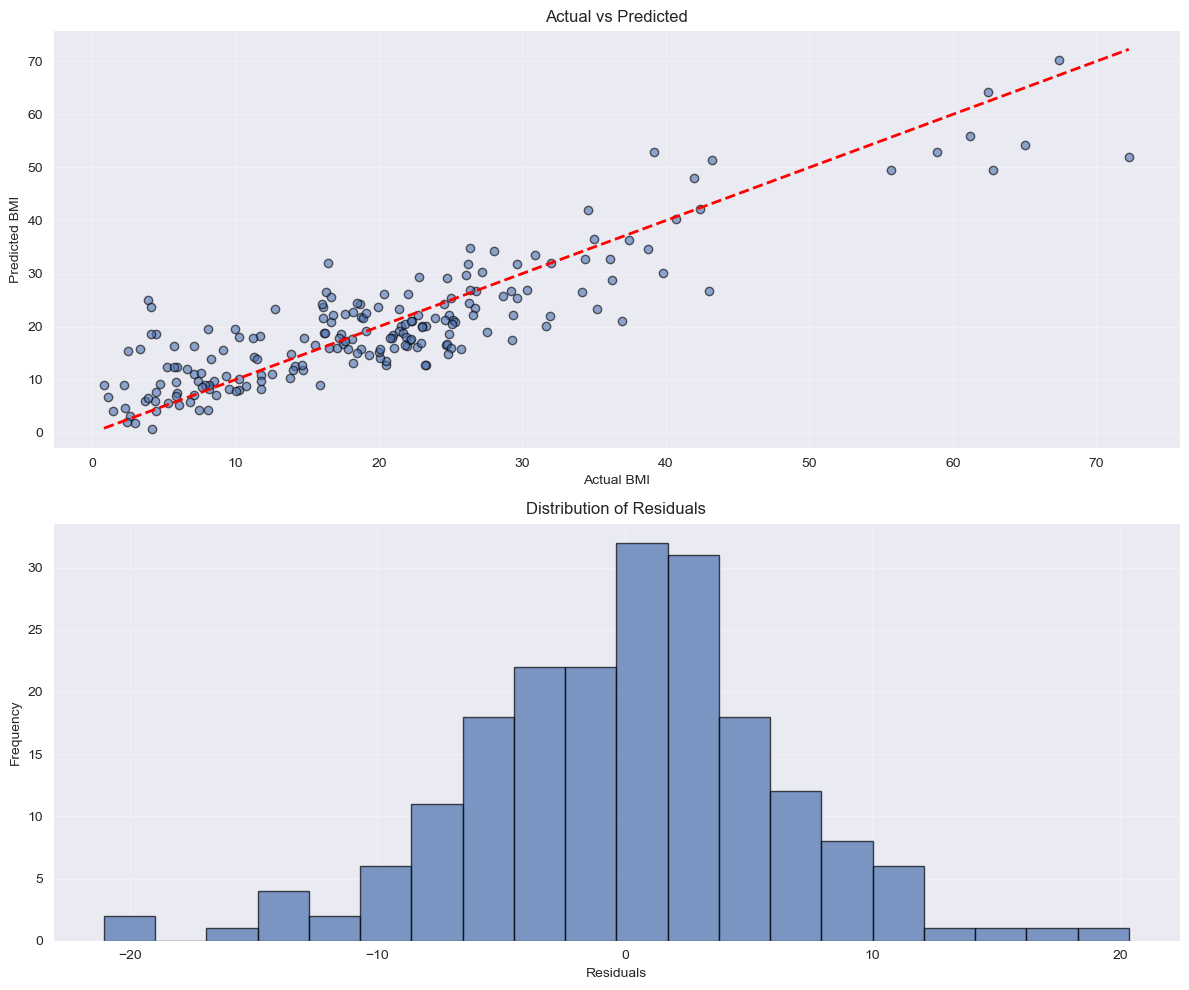

In [52]:
import scipy.stats as stats

residuals = full_model.resid
y_pred = full_model.predict()
y_actual = complete_indicators_data_2012['BMI'] 


# Get coefficients and confidence intervals        
params = full_model.params[1:]  # Exclude intercept
conf = full_model.conf_int().iloc[1:]  #Exclude intercept
errors = conf[1] - params  # Upper bound -estimate

fig, axes = plt.subplots(2, figsize=(12,10))

# 1. Actual vs Predicted
axes[0].scatter(y_actual, y_pred, alpha=0.6, edgecolors='k')
axes[0].plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual BMI')
axes[0].set_ylabel('Predicted BMI')
axes[0].set_title('Actual vs Predicted')        
axes[0].grid(alpha=0.3)


# 3. Histogram of residuals
axes[1].hist(residuals, bins=20,edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].grid(alpha=0.3)



plt.tight_layout()
plt.show()
